## Part II. Creating and testing photometric redshift estimators

### Goal.
Create a photometric redshift estimator using the scikit-learn tool-kit and test it out

### Metodology
1. Prepare the data for consumption by the machine learning algorithms, 
2. Use part of this data to train a regression model, 
3. Apply that regression model to remainder of the data
4. Investigate how well the regression model performed


##### We import packages we will need

In [1]:
import tables_io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from photoz_utils import *
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

##### Set the working directory to the project root directory

In [2]:
pz_dir = Path.cwd().parent

### Data

The main dataset (DP1) contains **83,989 measurements**. Due to Rubin Observatory data-access restrictions, the raw DP1 data are not redistributed in this repository. Instead, we use a **processed dataset**, derived from DP1, for training our machine learning models.

The **training set** contains **70% of the 9,683 measurements**.

The fundamental measurements considered here are the magnitudes associated with each photometric band, namely:

- {band}_psfMag
- {band}_gaap10Mag
- {band}_gaap3p0Mag
- {band}_cModelMag
- {band}_sersicMag


In [3]:
train = tables_io.read(f"{pz_dir}/data/dp1_matched_v4_train.hdf5")      # Reading the trainig set
test = tables_io.read(f"{pz_dir}/data/dp1_matched_v4_test.hdf5")        # Reading the test set
print(train.keys())

odict_keys(['confidence', 'coord_dec', 'coord_ra', 'ebv', 'euclid_h_unifMag', 'euclid_h_unifMagErr', 'euclid_j_unifMag', 'euclid_j_unifMagErr', 'euclid_vis_psfMag', 'euclid_vis_psfMagErr', 'euclid_y_unifMag', 'euclid_y_unifMagErr', 'ext_class', 'g_cModelMag', 'g_cModelMagErr', 'g_gaap1p0Mag', 'g_gaap1p0MagErr', 'g_gaap3p0Mag', 'g_gaap3p0MagErr', 'g_kronMag', 'g_kronMagErr', 'g_psfMag', 'g_psfMagErr', 'g_sersicMag', 'g_sersicMagErr', 'i_cModelMag', 'i_cModelMagErr', 'i_gaap1p0Mag', 'i_gaap1p0MagErr', 'i_gaap3p0Mag', 'i_gaap3p0MagErr', 'i_kronMag', 'i_kronMagErr', 'i_psfMag', 'i_psfMagErr', 'i_sersicMag', 'i_sersicMagErr', 'objectId', 'r_cModelMag', 'r_cModelMagErr', 'r_gaap1p0Mag', 'r_gaap1p0MagErr', 'r_gaap3p0Mag', 'r_gaap3p0MagErr', 'r_kronMag', 'r_kronMagErr', 'r_psfMag', 'r_psfMagErr', 'r_sersicMag', 'r_sersicMagErr', 'redshift', 'refExtendedness', 'snr_i_cModel', 'snr_i_gaap1p0', 'u_cModelMag', 'u_cModelMagErr', 'u_gaap1p0Mag', 'u_gaap1p0MagErr', 'u_gaap3p0Mag', 'u_gaap3p0MagErr', 

### We extract "features" and "targets" from the input data
We build the same features the same ways as the notebook '01_data_preprocessing.ipynb':

<p align="center">
    <img src="../images/features_and_targets.png" width="700">
</p>

<p align="center">
    <em>**Figure 1:** Feature set constructed for training the machine learning models.</em>
</p>

In [4]:
train_targets, train_features = data_preprocessing.prepare_data_total_mag_and_colors(train, '{band}_psfMag', 'ugrizy')
test_targets, test_features = data_preprocessing.prepare_data_total_mag_and_colors(test, '{band}_psfMag', 'ugrizy')

#### Data Scaling

The data are standardized to ensure a comparable feature scale, following

$$
x_{\mathrm{scaled}} = \frac{x - \mu}{\sigma}
$$

where $\mu$ and $\sigma$ are the mean and standard deviation, respectively. We additionally remove outliers outside the range **−5 to 5** in the scaled space to reduce the impact of extreme values.

In [5]:
scaler = StandardScaler().fit(train_features)
train_features_scaled = scaler.transform(train_features).clip(-5,5)        
test_features_scaled = scaler.transform(test_features).clip(-5,5)

#### PCA

Here, we apply Principal Component Analysis (PCA) to reduce the dimensionality of the feature space while preserving most of the variance in the data. PCA constructs a new set of orthogonal variables, called principal components, obtained through a linear transformation,

$$
\mathbf{z} = \mathbf{W}^{T}\mathbf{x},
$$

where $\mathbf{x}$ represents the original feature vector and $\mathbf{W}$ contains the directions of maximum variance (principal components). This transformation helps reduce redundancy and improve computational efficiency.

In [6]:
pca = PCA(n_components=train_features_scaled.shape[-1], whiten=False)
pca.fit(train_features_scaled.clip(-5, 5))

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",6
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

#### Explained Variance Ratio

The attribute `pca.explained_variance_ratio_` represents the fraction of the total variance explained by each principal component,

$$
r_i = \frac{\lambda_i}{\sum_j \lambda_j},
$$

where $\lambda_i$ denotes the eigenvalue associated with the $i$-th principal component. This quantity is useful to evaluate how much information is retained after dimensionality reduction.

In [7]:
pca.explained_variance_ratio_

array([0.41859298, 0.20153603, 0.15463422, 0.10069199, 0.08515449,
       0.03939028])

We apply PCA to the training and test features

In [8]:
train_features_pca = pca.transform(train_features_scaled)
test_features_pca = pca.transform(test_features_scaled)

#### we import all the different Estimation methods
A  "Regressor" is a python object that implements a machine learning method to build a regression model that tries to predict a value from features the data.

In [9]:
from sklearn.ensemble import (HistGradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import HuberRegressor, LinearRegression, QuantileRegressor
from sklearn.svm import NuSVR
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from xgboost import XGBClassifier

In [10]:
knr = KNeighborsRegressor()
hbr = HistGradientBoostingRegressor()
etr = ExtraTreesRegressor()
abr = AdaBoostRegressor()
gpr = GaussianProcessRegressor()
lir = LinearRegression()
#xgb = XGBClassifier()

### Model Training and Evaluation

We train the estimators and compute performance metrics such as **robust bias**, **robust scatter**, and the **outlier rate**.

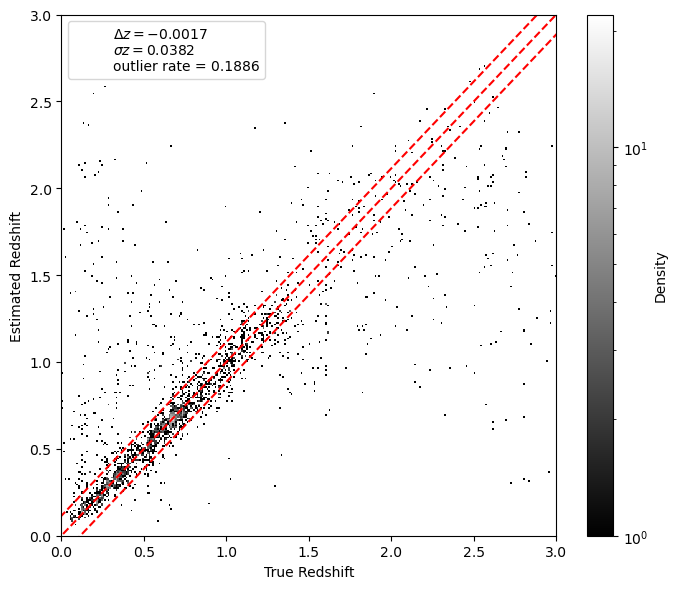

In [11]:
#preds = utility_functions.run_regression(knr, train_features_pca, train_targets, test_features_pca)
#_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)
preds = utility_functions.run_regression(knr, train_features_pca, train_targets, test_features_pca)
_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)

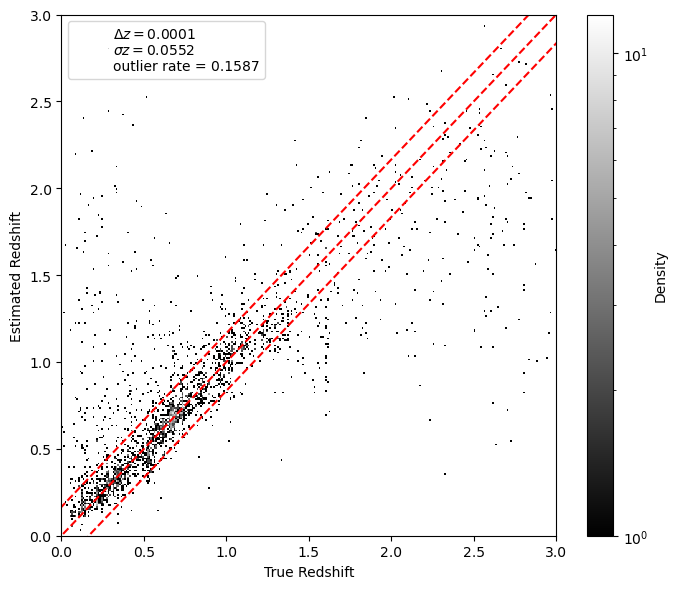

In [12]:
preds = utility_functions.run_regression(hbr, train_features_pca, train_targets, test_features_pca)
_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)

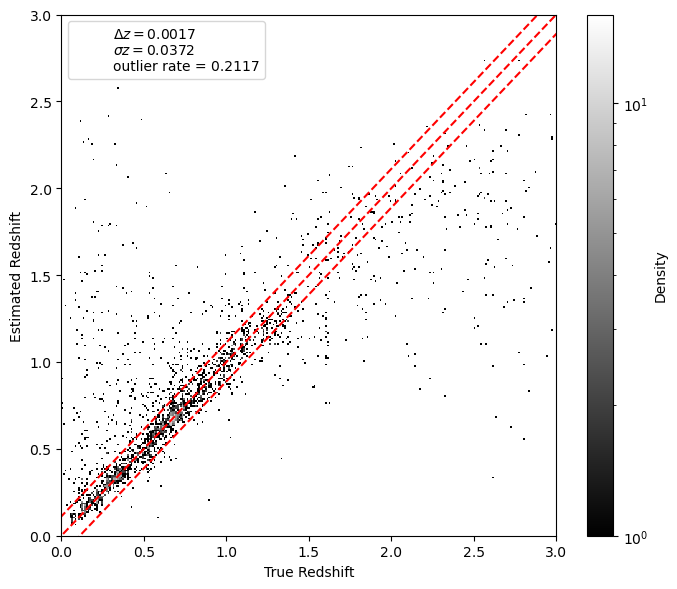

In [13]:
preds = utility_functions.run_regression(etr, train_features_pca, train_targets, test_features_pca)
_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)

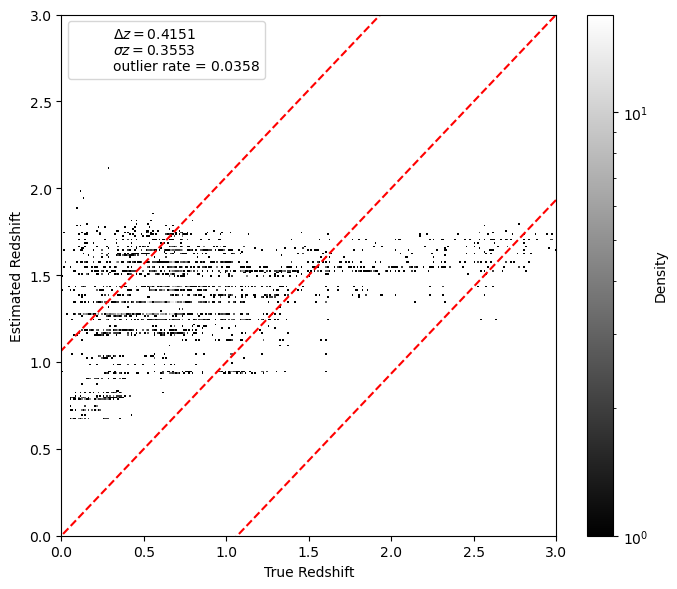

In [14]:
preds = utility_functions.run_regression(abr, train_features_pca, train_targets, test_features_pca)
_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)

In [15]:
#preds = utility_functions.run_regression(gpr, train_features_pca, train_targets, test_features_pca)
#_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)

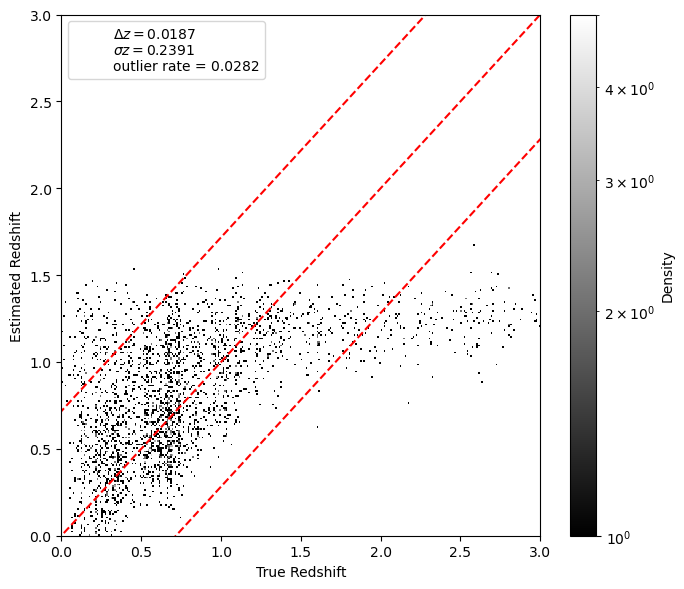

In [16]:
preds = utility_functions.run_regression(lir, train_features_pca, train_targets, test_features_pca)
_ = plotting_functions.plot_true_predict_fancy(test_targets, preds)